# 07 — Continual LM demo (HOPE vs MiniTransformer)

Train each model on **domain A** (TinyShakespeare), then on **domain B** (random alphabet sequences over the same vocab), and re-measure cross-entropy on domain A.

Catastrophic forgetting shows up as a large gap between the *before* and *after* bars. HOPE's CMS is supposed to make that gap smaller than the vanilla Transformer.

Paper reference: §7.1 (CMS protects long-term knowledge), §9.1 (continual-learning experiments).

In [1]:
import os, sys
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO not in sys.path: sys.path.insert(0, REPO)

import argparse
from scripts.benchmark import scenario_continual, ASSETS_DIR
from IPython.display import Image, display


In [2]:
args = argparse.Namespace(
    batch_size=4,
    seq_len=64,
    steps=30,
    lr=1e-3,
)
results = scenario_continual(args)
print(results)


[continual] hope: lossA before=4.128 after=4.135


[continual] transformer: lossA before=3.403 after=3.986
[continual] saved /Users/rlaope/Desktop/khope/hope-architecture/assets/bench_continual.png
{'hope': (4.127651786804199, 4.134592914581299), 'transformer': (3.4031260013580322, 3.986220598220825)}


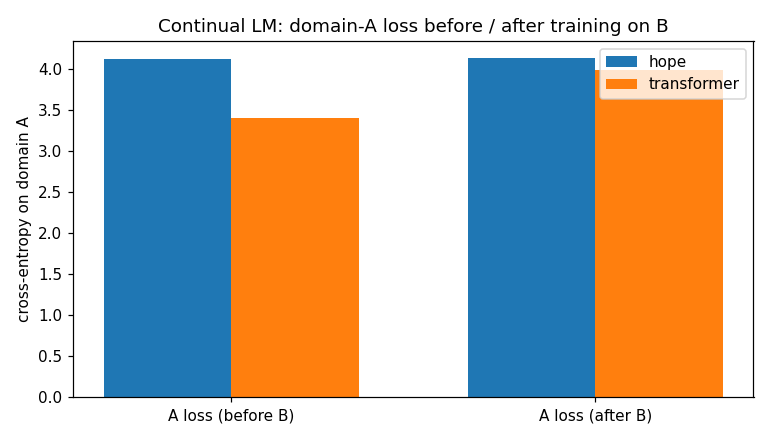

In [3]:
display(Image(os.path.join(ASSETS_DIR, 'bench_continual.png')))


Read the chart side by side: the *after-B* bar minus the *before-B* bar is the forgetting penalty. Smaller is better. With only 30 Adam steps per domain and a tiny model this is a smoke test, not a definitive measurement — but the shape of the gap is the thing to watch.